# Heart Disease Prediction using Machine Learning
**Dataset:** Cleveland Heart Disease Dataset (UCI)
**Algorithm:** Random Forest + Logistic Regression
**Platform:** Google Colab (Free)

---
### What this project does
We predict whether a patient has heart disease based on 13 health measurements like chest pain type, cholesterol, and blood pressure. Output is either `1` (Heart Disease) or `0` (No Heart Disease).

**Run each cell by pressing `Shift + Enter`**

In [8]:
# CELL 1 — Import all libraries
# (All are pre-installed in Colab — nothing extra needed)

import pandas as pd                  # for loading and handling data
import numpy as np                   # for number calculations
import matplotlib.pyplot as plt      # for drawing charts
import seaborn as sns                # for prettier charts

from sklearn.model_selection import train_test_split   # splits data into train/test
from sklearn.ensemble import RandomForestClassifier    # ML model 1
from sklearn.linear_model import LogisticRegression   # ML model 2
from sklearn.metrics import (
    accuracy_score,          # how accurate the model is
    confusion_matrix,        # correct vs wrong predictions
    classification_report    # detailed performance report
)
from sklearn.preprocessing import StandardScaler       # normalises the data

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1 — Load the Dataset
We load directly from a public URL. **No download needed!**

In [9]:
# CELL 2 — Load the dataset

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)



print(f"Dataset loaded! Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
print(df.head())

# What each column means:
# age         — age of the patient
# sex         — 1 = male, 0 = female
# cp          — chest pain type (0-3)
# trestbps    — resting blood pressure
# chol        — cholesterol level
# fbs         — fasting blood sugar > 120 (1 = true, 0 = false)
# restecg     — resting ECG results
# thalach     — maximum heart rate achieved
# exang       — exercise induced chest pain (1 = yes, 0 = no)
# oldpeak     — ST depression during exercise
# slope       — slope of peak exercise ST segment
# ca          — number of major blood vessels (0-3)
# thal        — thalassemia type
# target      — 1 = heart disease, 0 = no heart disease

Dataset loaded! Shape: 303 rows x 14 columns

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


## Step 2 — Exploratory Data Analysis (EDA)

In [10]:
# CELL 3 — Look at and understand the data

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe().round(2))

print("\nMissing values:")
print(df.isnull().sum())

print("\nPatient count by Target:")
print(df["target"].value_counts())
print("(0 = No Heart Disease,  1 = Has Heart Disease)")

DATASET INFORMATION

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Summary statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200

### Chart 1 — How many patients have heart disease?

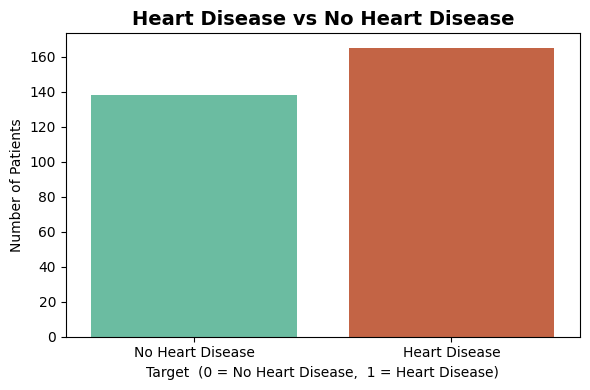

Chart 1 saved!


In [11]:
# CELL 4 — Chart 1: Count of patients with/without heart disease

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette=["#5DCAA5", "#D85A30"])
plt.title("Heart Disease vs No Heart Disease", fontsize=14, fontweight="bold")
plt.xlabel("Target  (0 = No Heart Disease,  1 = Heart Disease)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig("chart1_target_count.png", dpi=150)
plt.show()
print("Chart 1 saved!")

### Chart 2 — Age distribution of patients

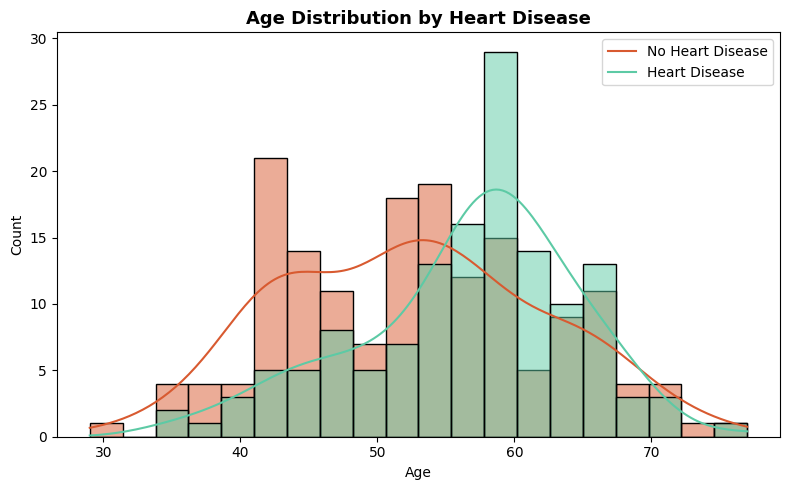

Chart 2 saved!


In [12]:
# CELL 5 — Chart 2: Age distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="target", bins=20,
             palette=["#5DCAA5", "#D85A30"], kde=True)
plt.title("Age Distribution by Heart Disease", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig("chart2_age_distribution.png", dpi=150)
plt.show()
print("Chart 2 saved!")

### Chart 3 — Correlation Heatmap

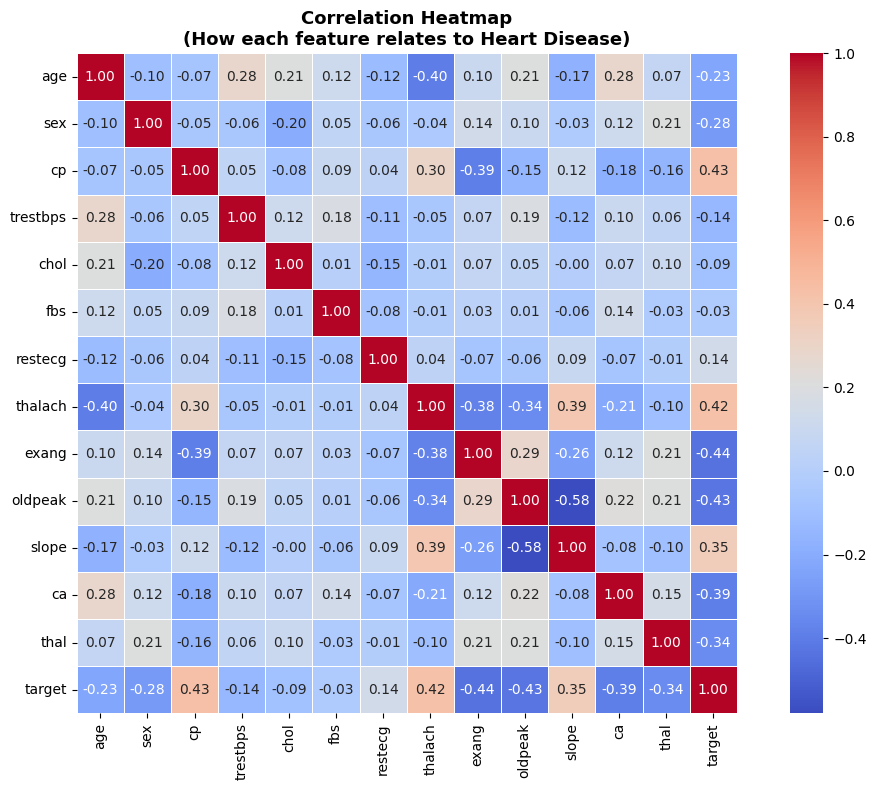

Chart 3 saved!


In [13]:
# CELL 6 — Chart 3: Correlation heatmap

plt.figure(figsize=(11, 8))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap\n(How each feature relates to Heart Disease)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart3_heatmap.png", dpi=150)
plt.show()
print("Chart 3 saved!")

### Chart 4 — Chest Pain Type vs Heart Disease

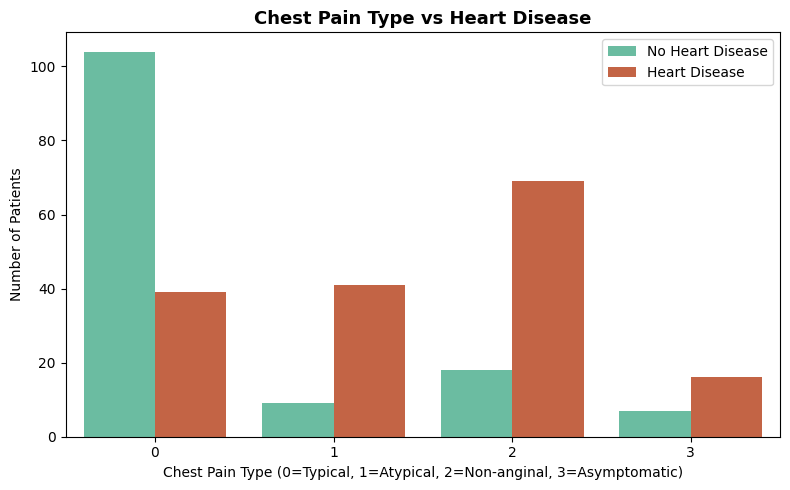

Chart 4 saved!
Key insight: Type 2 chest pain patients have higher heart disease risk!


In [14]:
# CELL 7 — Chart 4: Chest pain type vs heart disease
# cp = chest pain type
# 0 = typical angina, 1 = atypical angina, 2 = non-anginal, 3 = asymptomatic

plt.figure(figsize=(8, 5))
sns.countplot(x="cp", hue="target", data=df, palette=["#5DCAA5", "#D85A30"])
plt.title("Chest Pain Type vs Heart Disease", fontsize=13, fontweight="bold")
plt.xlabel("Chest Pain Type (0=Typical, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)")
plt.ylabel("Number of Patients")
plt.legend(["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig("chart4_chestpain_vs_target.png", dpi=150)
plt.show()
print("Chart 4 saved!")
print("Key insight: Type 2 chest pain patients have higher heart disease risk!")

### Chart 5 — Max Heart Rate vs Heart Disease

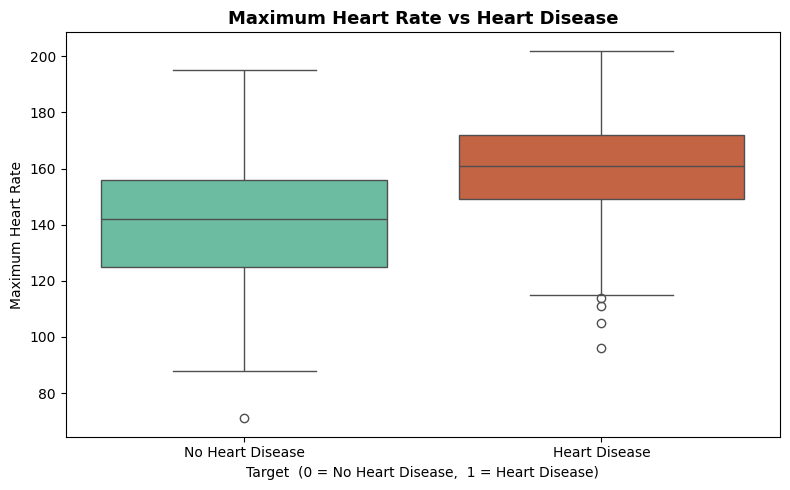

Chart 5 saved!
Key insight: Patients WITH heart disease have higher max heart rate!


In [15]:
# CELL 8 — Chart 5: Max heart rate vs target

plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="thalach", data=df, palette=["#5DCAA5", "#D85A30"])
plt.title("Maximum Heart Rate vs Heart Disease", fontsize=13, fontweight="bold")
plt.xlabel("Target  (0 = No Heart Disease,  1 = Heart Disease)")
plt.ylabel("Maximum Heart Rate")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig("chart5_heartrate_vs_target.png", dpi=150)
plt.show()
print("Chart 5 saved!")
print("Key insight: Patients WITH heart disease have higher max heart rate!")

## Step 3 — Prepare the Data

In [16]:
# CELL 9 — Separate features (X) and target (y)

# X = the 13 inputs the model learns from
# y = the answer (0 or 1) we want to predict
X = df.drop("target", axis=1)
y = df["target"]

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

Features (X) shape : (303, 13)
Target   (y) shape : (303,)

Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [17]:
# CELL 10 — Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 242
Testing samples  : 61


In [18]:
# CELL 11 — Scale the features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


## Step 4 — Train TWO Models and Compare
We will train Random Forest AND Logistic Regression and compare which one is better. This makes your project look more advanced!

In [19]:
# CELL 12 — Train Model 1: Random Forest

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred     = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy : {rf_accuracy * 100:.2f}%")

Random Forest Accuracy : 85.25%


In [20]:
# CELL 13 — Train Model 2: Logistic Regression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred     = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy : {lr_accuracy * 100:.2f}%")

Logistic Regression Accuracy : 80.33%


### Chart 6 — Model Comparison

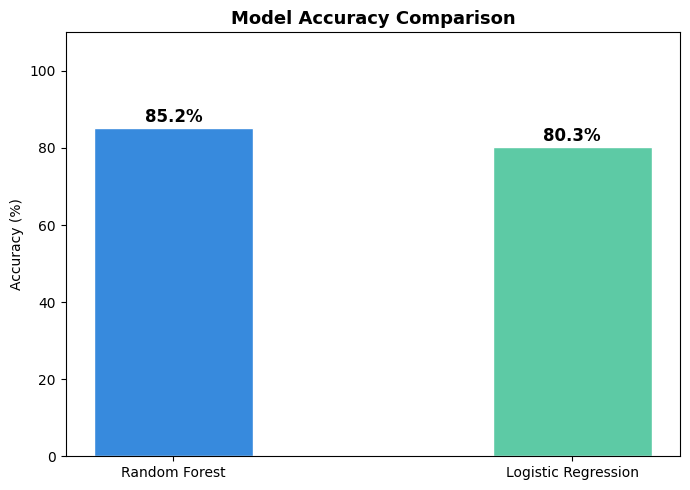

Chart 6 saved!

Best model: Random Forest with 85.25% accuracy


In [21]:
# CELL 14 — Chart 6: Compare both models visually

models     = ["Random Forest", "Logistic Regression"]
accuracies = [rf_accuracy * 100, lr_accuracy * 100]
colors     = ["#378ADD", "#5DCAA5"]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor="white", width=0.4)
plt.ylim(0, 110)
plt.title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy (%)")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{acc:.1f}%",
             ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("chart6_model_comparison.png", dpi=150)
plt.show()
print("Chart 6 saved!")

best_model     = "Random Forest" if rf_accuracy >= lr_accuracy else "Logistic Regression"
best_accuracy  = max(rf_accuracy, lr_accuracy)
print(f"\nBest model: {best_model} with {best_accuracy*100:.2f}% accuracy")

## Step 5 — Evaluate the Best Model

In [22]:
# CELL 15 — Detailed report of the best model

# We use whichever model performed better
if rf_accuracy >= lr_accuracy:
    best_pred  = rf_pred
    best_model = rf_model
    print("Using Random Forest (best model)")
else:
    best_pred  = lr_pred
    best_model = lr_model
    print("Using Logistic Regression (best model)")

print("\n" + "=" * 50)
print("       MODEL PERFORMANCE")
print("=" * 50)
print(f"\nAccuracy : {max(rf_accuracy, lr_accuracy) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, best_pred,
      target_names=["No Heart Disease", "Heart Disease"]))

Using Random Forest (best model)

       MODEL PERFORMANCE

Accuracy : 85.25%

Detailed Report:
                  precision    recall  f1-score   support

No Heart Disease       0.95      0.71      0.82        28
   Heart Disease       0.80      0.97      0.88        33

        accuracy                           0.85        61
       macro avg       0.88      0.84      0.85        61
    weighted avg       0.87      0.85      0.85        61



### Chart 7 — Confusion Matrix

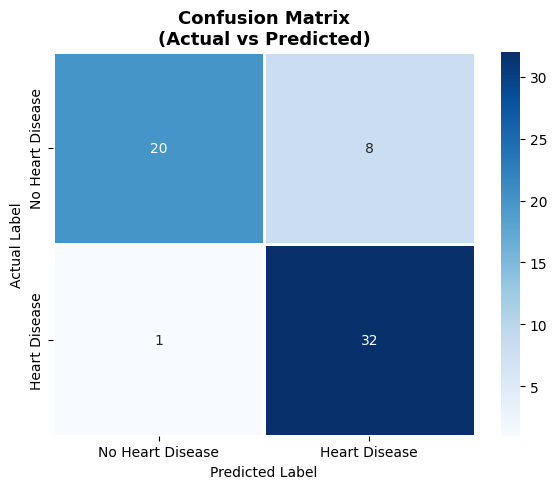

Correctly predicted No Heart Disease : 20
Correctly predicted Heart Disease    : 32
Wrongly predicted Heart Disease      : 8
Missed actual Heart Disease cases    : 1


In [23]:
# CELL 16 — Chart 7: Confusion matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Heart Disease", "Heart Disease"],
            yticklabels=["No Heart Disease", "Heart Disease"],
            linewidths=1)
plt.title("Confusion Matrix\n(Actual vs Predicted)", fontsize=13, fontweight="bold")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("chart7_confusion_matrix.png", dpi=150)
plt.show()

TP = cm[1][1]; TN = cm[0][0]; FP = cm[0][1]; FN = cm[1][0]
print(f"Correctly predicted No Heart Disease : {TN}")
print(f"Correctly predicted Heart Disease    : {TP}")
print(f"Wrongly predicted Heart Disease      : {FP}")
print(f"Missed actual Heart Disease cases    : {FN}")

### Chart 8 — Feature Importance

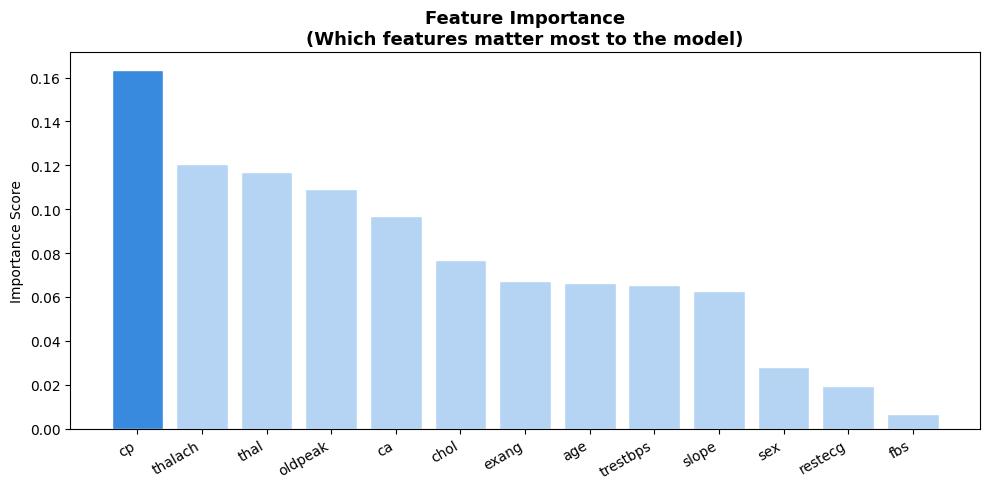

Most important feature: CP


In [24]:
# CELL 17 — Chart 8: Feature importance (Random Forest only)

feature_names = list(X.columns)
importances   = rf_model.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances[indices],
        color=["#378ADD" if importances[i] == max(importances) else "#B5D4F4"
               for i in indices],
        edgecolor="white")
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=30, ha="right", fontsize=10)
plt.title("Feature Importance\n(Which features matter most to the model)",
          fontsize=13, fontweight="bold")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("chart8_feature_importance.png", dpi=150)
plt.show()
print(f"Most important feature: {feature_names[indices[0]].upper()}")

## Step 6 — Predict for a New Patient

In [25]:
# CELL 18 — Predict for a new patient

print("=" * 50)
print("   PREDICTING FOR A NEW PATIENT")
print("=" * 50)

# You can change these values to test different patients!
new_patient = pd.DataFrame({
    "age":      [55],
    "sex":      [1],       # 1 = male, 0 = female
    "cp":       [2],       # chest pain type
    "trestbps": [130],     # resting blood pressure
    "chol":     [250],     # cholesterol
    "fbs":      [0],       # fasting blood sugar
    "restecg":  [1],       # resting ECG
    "thalach":  [165],     # max heart rate
    "exang":    [0],       # exercise induced chest pain
    "oldpeak":  [1.2],     # ST depression
    "slope":    [2],       # slope
    "ca":       [0],       # number of vessels
    "thal":     [2]        # thalassemia
})

new_scaled  = scaler.transform(new_patient)
prediction  = rf_model.predict(new_scaled)
probability = rf_model.predict_proba(new_scaled)[0]

print("\nPatient details:")
for col in new_patient.columns:
    print(f"  {col:<12}: {new_patient[col].values[0]}")

result = "HEART DISEASE DETECTED" if prediction[0] == 1 else "NO HEART DISEASE"
print(f"\nPrediction           : {result}")
print(f"Confidence           : {max(probability) * 100:.1f}%")
print(f"Risk of Heart Disease: {probability[1] * 100:.1f}%")

   PREDICTING FOR A NEW PATIENT

Patient details:
  age         : 55
  sex         : 1
  cp          : 2
  trestbps    : 130
  chol        : 250
  fbs         : 0
  restecg     : 1
  thalach     : 165
  exang       : 0
  oldpeak     : 1.2
  slope       : 2
  ca          : 0
  thal        : 2

Prediction           : HEART DISEASE DETECTED
Confidence           : 94.1%
Risk of Heart Disease: 94.1%


## Project Summary

In [26]:
# CELL 19 — Final summary

best_acc = max(rf_accuracy, lr_accuracy) * 100
best_name = "Random Forest" if rf_accuracy >= lr_accuracy else "Logistic Regression"

print("=" * 55)
print("    PROJECT SUMMARY — HEART DISEASE PREDICTION")
print("=" * 55)
print(f"  Dataset       : Cleveland Heart Disease (UCI)")
print(f"  Total Samples : {len(df)} patients")
print(f"  Features      : 13 health measurements")
print(f"  Models Tried  : Random Forest + Logistic Regression")
print(f"  Best Model    : {best_name}")
print(f"  Best Accuracy : {best_acc:.2f}%")
print(f"  Top Feature   : {feature_names[indices[0]]}")
print("=" * 55)
print("\n  Charts generated:")
print("  1. chart1_target_count.png")
print("  2. chart2_age_distribution.png")
print("  3. chart3_heatmap.png")
print("  4. chart4_chestpain_vs_target.png")
print("  5. chart5_heartrate_vs_target.png")
print("  6. chart6_model_comparison.png")
print("  7. chart7_confusion_matrix.png")
print("  8. chart8_feature_importance.png")
print("\n  Upload this .ipynb to GitHub!")
print("=" * 55)

    PROJECT SUMMARY — HEART DISEASE PREDICTION
  Dataset       : Cleveland Heart Disease (UCI)
  Total Samples : 303 patients
  Features      : 13 health measurements
  Models Tried  : Random Forest + Logistic Regression
  Best Model    : Random Forest
  Best Accuracy : 85.25%
  Top Feature   : cp

  Charts generated:
  1. chart1_target_count.png
  2. chart2_age_distribution.png
  3. chart3_heatmap.png
  4. chart4_chestpain_vs_target.png
  5. chart5_heartrate_vs_target.png
  6. chart6_model_comparison.png
  7. chart7_confusion_matrix.png
  8. chart8_feature_importance.png

  Upload this .ipynb to GitHub!
